<a href="https://colab.research.google.com/github/kyjness/personal/blob/Code/H%26M_%EA%B0%9C%EC%9D%B8_%EB%A7%9E%EC%B6%A4_%ED%8C%A8%EC%85%98_%EC%B6%94%EC%B2%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#탐색적 자료분석

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
import pandas as pd
import numpy as np

ar = pd.read_csv('/content/drive/MyDrive/competition/H&M 개인 맞춤 패션 추천/articles.csv/articles.csv')
cu = pd.read_csv('/content/drive/MyDrive/competition/H&M 개인 맞춤 패션 추천/customers.csv/customers.csv')
sub = pd.read_csv('/content/drive/MyDrive/competition/H&M 개인 맞춤 패션 추천/sample_submission.csv/sample_submission.csv')
tr = pd.read_csv('/content/drive/MyDrive/competition/H&M 개인 맞춤 패션 추천/transactions_train.csv/transactions_train.csv')
ar.head()

,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,...,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
0,108775015,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,9,Black,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
1,108775044,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,10,White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
2,108775051,108775,Strap top (1),253,Vest top,Garment Upper body,1010017,Stripe,11,Off White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
3,110065001,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,9,Black,...,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."
4,110065002,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,10,White,...,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."


In [ ]:
cu.head()

,customer_id,FN,Active,club_member_status,fashion_news_frequency,age,postal_code
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,NaN,NaN,ACTIVE,NONE,49.0,52043ee2162cf5aa7ee79974281641c6f11a68d276429a...
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,NaN,NaN,ACTIVE,NONE,25.0,2973abc54daa8a5f8ccfe9362140c63247c5eee03f1d93...
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,NaN,NaN,ACTIVE,NONE,24.0,64f17e6a330a85798e4998f62d0930d14db8db1c054af6...
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,NaN,NaN,ACTIVE,NONE,54.0,5d36574f52495e81f019b680c843c443bd343d5ca5b1c2...
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,1.0,1.0,ACTIVE,Regularly,52.0,25fa5ddee9aac01b35208d01736e57942317d756b32ddd...


In [ ]:
tr.head()

,t_dat,customer_id,article_id,price,sales_channel_id
0,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,663713001,0.050831,2
1,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,541518023,0.030492,2
2,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,505221004,0.015237,2
3,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687003,0.016932,2
4,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687004,0.016932,2


In [ ]:
ar.info()
cu.info()
tr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105542 entries, 0 to 105541
Data columns (total 25 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   article_id                    105542 non-null  int64 
 1   product_code                  105542 non-null  int64 
 2   prod_name                     105542 non-null  object
 3   product_type_no               105542 non-null  int64 
 4   product_type_name             105542 non-null  object
 5   product_group_name            105542 non-null  object
 6   graphical_appearance_no       105542 non-null  int64 
 7   graphical_appearance_name     105542 non-null  object
 8   colour_group_code             105542 non-null  int64 
 9   colour_group_name             105542 non-null  object
 10  perceived_colour_value_id     105542 non-null  int64 
 11  perceived_colour_value_name   105542 non-null  object
 12  perceived_colour_master_id    105542 non-null  int64 
 13 

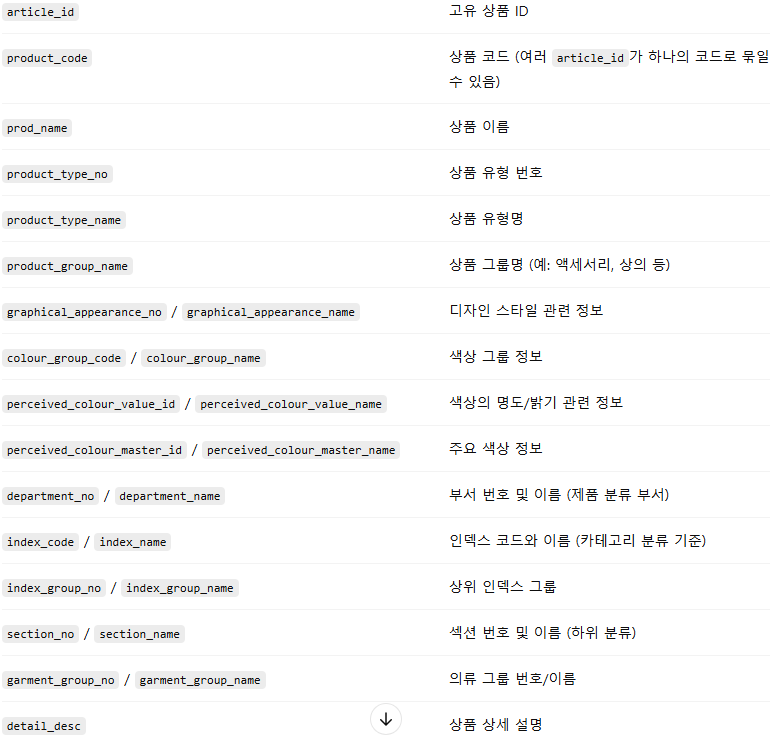

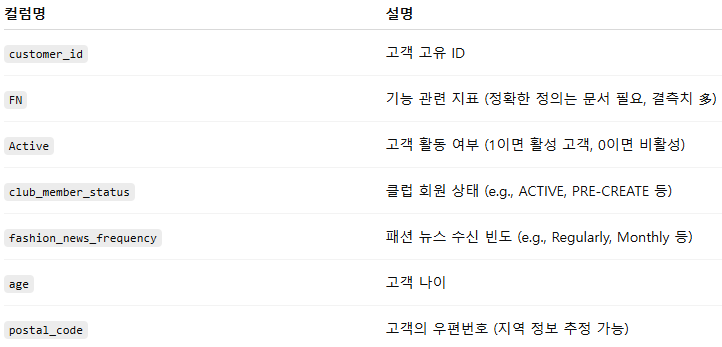

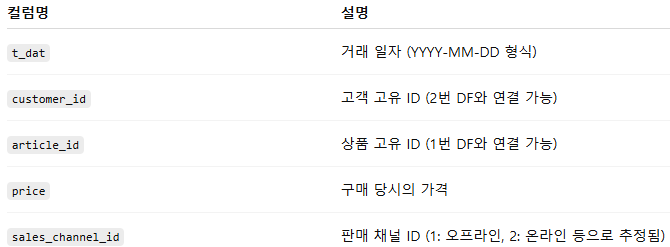

In [ ]:
#데이터 타입 변경
tr['t_dat'] = pd.to_datetime(tr['t_dat'], format='%Y-%m-%d')
tr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31788324 entries, 0 to 31788323
Data columns (total 5 columns):
 #   Column            Dtype         
---  ------            -----         
 0   t_dat             datetime64[ns]
 1   customer_id       object        
 2   article_id        int64         
 3   price             float64       
 4   sales_channel_id  int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 1.2+ GB


##상위 유저 비율에 따른 누적 구매 기여도

In [ ]:
tr.groupby('customer_id').size().reset_index(name='purchase_count').sort_values(by='purchase_count', ascending=False)

,customer_id,purchase_count
1011710,be1981ab818cf4ef6765b2ecaea7a2cbf14ccd6e8a7ee9...,1895
962395,b4db5e5259234574edfff958e170fe3a5e13b6f146752c...,1441
391840,49beaacac0c7801c2ce2d189efe525fe80b5d37e46ed05...,1364
885174,a65f77281a528bf5c1e9f270141d601d116e1df33bf9df...,1361
1090960,cd04ec2726dd58a8c753e0d6423e57716fd9ebcf2f14ed...,1237
...,...,...
832233,9c7945de9cd5a5d7f833476ee2d7739e82b180a2026b5c...,1
234335,2c0f5a51c0b29188a119bdd358897f279b1dda4ba0194b...,1
234337,2c0f6e18e2e825f006126fc8be1117928fa24d5810857a...,1
832215,9c784d9b315f5c761a2f6c267f88d7f9bb4d8597b7983f...,1


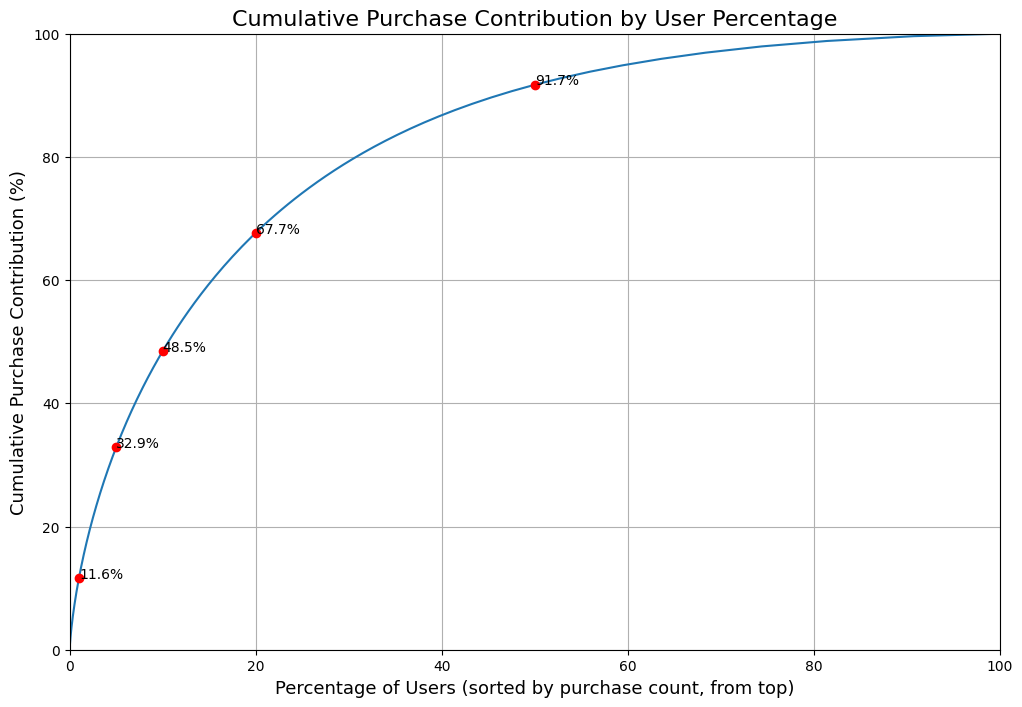

상위 1% 유저는 전체 구매의 11.64%를 기여합니다.
상위 5% 유저는 전체 구매의 32.85%를 기여합니다.
상위 10% 유저는 전체 구매의 48.47%를 기여합니다.
상위 20% 유저는 전체 구매의 67.67%를 기여합니다.
상위 50% 유저는 전체 구매의 91.71%를 기여합니다.


In [ ]:
# 시각화를 위해 누적 비율을 포함한 DataFrame 생성
user_purchase_counts = tr.groupby('customer_id').size().reset_index(name='purchase_count')
user_purchase_counts = user_purchase_counts.sort_values(by='purchase_count', ascending=False)

# 누적 구매 기여도 계산
user_purchase_counts['cumulative_purchase_count'] = user_purchase_counts['purchase_count'].cumsum()
total_purchases = user_purchase_counts['purchase_count'].sum()
user_purchase_counts['cumulative_contribution'] = (user_purchase_counts['cumulative_purchase_count'] / total_purchases) * 100

# 누적 사용자 비율 계산
user_purchase_counts['user_cumulative_percentage'] = (np.arange(len(user_purchase_counts)) + 1) / len(user_purchase_counts) * 100

# 시각화
plt.figure(figsize=(12, 8))
sns.lineplot(x='user_cumulative_percentage', y='cumulative_contribution', data=user_purchase_counts)

# 그래프에 주요 포인트 추가 (예: 상위 1%, 5%, 10%, 20%, 50%)
for percent in [1, 5, 10, 20, 50]:
    if percent <= 100:
        num_users_at_percent = int(len(user_purchase_counts) * (percent / 100))
        # Ensure index is within bounds
        if num_users_at_percent > 0 and num_users_at_percent <= len(user_purchase_counts):
            # Adjust index for 0-based indexing
            user_index = num_users_at_percent - 1 if num_users_at_percent > 0 else 0
            contribution_at_percent = user_purchase_counts['cumulative_contribution'].iloc[user_index]
            plt.plot(percent, contribution_at_percent, 'ro') # Mark the point
            plt.text(percent, contribution_at_percent, f'{contribution_at_percent:.1f}%', fontsize=10, ha='left')

plt.title('Cumulative Purchase Contribution by User Percentage', fontsize=16)
plt.xlabel('Percentage of Users (sorted by purchase count, from top)', fontsize=13)
plt.ylabel('Cumulative Purchase Contribution (%)', fontsize=13)
plt.grid(True)
plt.xlim(0, 100) # Set x-axis limit to 0-100%
plt.ylim(0, 100) # Set y-axis limit to 0-100%
plt.show()

# 상위 몇 프로 유저의 누적 기여도 출력
for percent in [1, 5, 10, 20, 50]:
    if percent <= 100:
        num_users_at_percent = int(len(user_purchase_counts) * (percent / 100))
         # Ensure index is within bounds
        if num_users_at_percent > 0 and num_users_at_percent <= len(user_purchase_counts):
            # Adjust index for 0-based indexing
            user_index = num_users_at_percent - 1 if num_users_at_percent > 0 else 0
            contribution_at_percent = user_purchase_counts['cumulative_contribution'].iloc[user_index]
            print(f"상위 {percent}% 유저는 전체 구매의 {contribution_at_percent:.2f}%를 기여합니다.")


##연도-월별 분석

In [ ]:
tr['year_month'] = tr['t_dat'].dt.to_period('M').astype(str)
tr.head()

,t_dat,customer_id,article_id,price,sales_channel_id,year_month
0,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,663713001,0.050831,2,2018-09
1,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,541518023,0.030492,2,2018-09
2,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,505221004,0.015237,2,2018-09
3,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687003,0.016932,2,2018-09
4,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687004,0.016932,2,2018-09


In [ ]:
price_by_month = tr.groupby(['year_month'])[['price']].sum().reset_index()
price_by_month.sort_values(by='price', ascending=False).head()

,year_month,price
9,2019-06,48648.417864
8,2019-05,43357.502322
21,2020-06,43055.359068
7,2019-04,42824.987305
1,2018-10,41584.816610


In [ ]:
fig = px.line(data_frame=price_by_month, x="year_month", y="price")
fig.show()

In [ ]:
print("가장 빠른 날짜:", tr['t_dat'].min())
print("가장 느린 날짜:", tr['t_dat'].max())

가장 빠른 날짜: 2018-09-20 00:00:00
가장 느린 날짜: 2020-09-22 00:00:00


In [ ]:
# 연도별 판매 수익
tr['year'] = tr['t_dat'].dt.year
price_by_year = tr.groupby(['year'])[['price']].sum().reset_index()
print("\n연도별 판매 수익:")
print(price_by_year)

fig_year = px.line(data_frame=price_by_year, x="year", y="price", title="연도별 판매 수익")
fig_year.show()


연도별 판매 수익:
   year          price
0  2018  130873.959305
1  2019  455604.877966
2  2020  298167.136780


In [ ]:
# 월별 평균 판매 수익
tr['month'] = tr['t_dat'].dt.month
price_by_month_avg = tr.groupby(['month'])[['price']].mean().reset_index()
print("\n월별 평균 판매 수익:")
print(price_by_month_avg)

fig_month_avg = px.line(data_frame=price_by_month_avg, x="month", y="price", title="월별 평균 판매 수익")
fig_month_avg.update_xaxes(dtick=1)
fig_month_avg.show()


월별 평균 판매 수익:
    month     price
0       1  0.026602
1       2  0.027954
2       3  0.029053
3       4  0.028620
4       5  0.027549
5       6  0.024983
6       7  0.023030
7       8  0.025565
8       9  0.032388
9      10  0.030888
10     11  0.031538
11     12  0.028141


In [ ]:
# 월별 구매 빈도 계산
monthly_purchases = tr.groupby('month').size().reset_index(name='purchase_count')
print("\n월별 구매 빈도:")
print(monthly_purchases)

# 월별 구매 빈도
fig_monthly_px = px.line(data_frame=monthly_purchases, x="month", y="purchase_count", title="월별 구매 빈도")
fig_monthly_px.update_xaxes(dtick=1)
fig_monthly_px.show()


월별 구매 빈도:
    month  purchase_count
0       1         2339825
1       2         2154271
2       3         2334502
3       4         2817336
4       5         2922134
5       6         3670709
6       7         3158996
7       8         2490722
8       9         2620223
9      10         2543812
10     11         2468652
11     12         2267142


##연령대별로 인기있는 옷 종류는?

In [ ]:
from os.path import exists
import matplotlib.pyplot as plt
import cv2

In [ ]:
cu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1371980 entries, 0 to 1371979
Data columns (total 7 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   customer_id             1371980 non-null  object 
 1   FN                      476930 non-null   float64
 2   Active                  464404 non-null   float64
 3   club_member_status      1365918 non-null  object 
 4   fashion_news_frequency  1355969 non-null  object 
 5   age                     1356119 non-null  float64
 6   postal_code             1371980 non-null  object 
dtypes: float64(3), object(4)
memory usage: 73.3+ MB


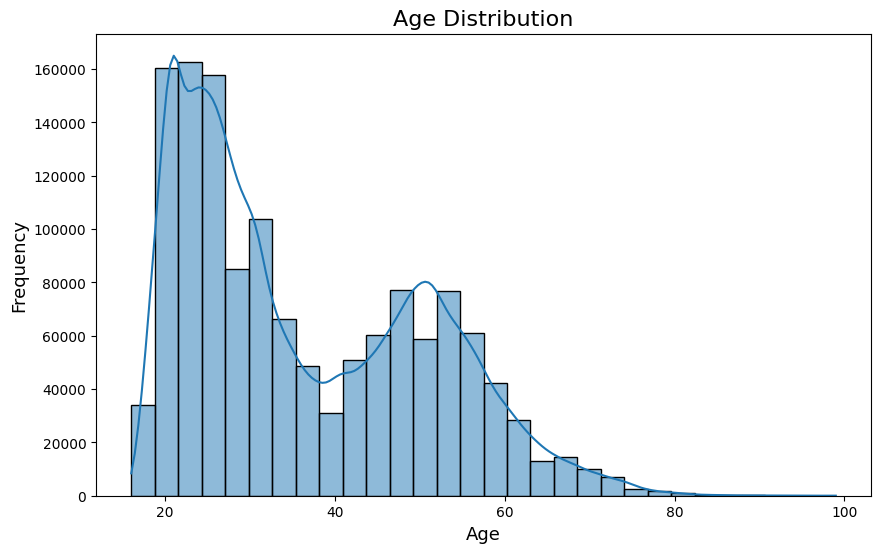

In [ ]:
# 연령대 분포 확인
plt.figure(figsize=(10, 6))
sns.histplot(data=cu, x='age', bins=30, kde=True)
plt.title('Age Distribution', fontsize=16)
plt.xlabel('Age', fontsize=13)
plt.ylabel('Frequency', fontsize=13)
plt.show()

In [ ]:
# 연령 정보 결합
customer_transactions = tr.merge(cu[['customer_id', 'age']], on='customer_id', how='left')

# 연령대 분류 (10세 단위: 0-9, 10-19, ..., 90-99)
bins = list(range(0, 101, 10))
labels = [f'{i}-{i+9}' for i in range(0, 100, 10)]
customer_transactions['age_group'] = pd.cut(customer_transactions['age'], bins=bins, labels=labels, right=False)

# 전체 판매량 기준 상위 1000개 상품 ID 추출 (기본템)
overall_top1000 = tr["article_id"].value_counts().head(1000).index

# 연령대별 x 상품별 판매량 계산
age_group_sales = customer_transactions.groupby(['age_group', 'article_id']).size().reset_index(name='sales_count')

# 상위 1000개 상품 제거
age_group_sales = age_group_sales[~age_group_sales["article_id"].isin(overall_top1000)].reset_index(drop=True)

# 연령대별 상위 5개 추출
top_n = 5
hit_items_by_age_group = age_group_sales.groupby("age_group").apply(lambda x: x.nlargest(top_n, "sales_count")).reset_index(drop=True)

# 시각화
BASE = '/content/drive/MyDrive/competition/H&M 개인 맞춤 패션 추천/images'

for age_group in hit_items_by_age_group['age_group'].unique():
    print(f"\n연령대: {age_group} - 상위 {top_n}개 히트 상품:")
    age_group_df = hit_items_by_age_group[hit_items_by_age_group['age_group'] == age_group]
    print(age_group_df[['article_id', 'sales_count']])

    # 히트 상품 시각화 (각 연령대별 상위 5개 상품 이미지 출력)
    age_group_article_ids = age_group_df['article_id'].tolist()
    plt.figure(figsize=(20, 4))
    shown = 0
    for article_id in age_group_article_ids:
        img_path = BASE + '/0' + str(article_id)[:2] + '/0' + str(article_id) + '.jpg'
        if exists(img_path):
            img = cv2.imread(img_path)[:, :, ::-1]
            if shown < top_n: # Ensure we only plot top_n
                plt.subplot(1, top_n, shown + 1)
                plt.imshow(img)
                plt.title(f'Item: {article_id}', fontsize=10)
                plt.axis('off')
                shown += 1
        else:
            print(f"Image not found for article ID: {article_id}")
            if shown < top_n: # Still try to show something if image not found
                 plt.subplot(1, top_n, shown + 1)
                 plt.text(0.5, 0.5, f'No Image\n{article_id}', horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=10)
                 plt.axis('off')
                 shown += 1

    plt.tight_layout()
    plt.show()

#베이스라인

In [ ]:
tr.head()

,t_dat,customer_id,article_id,price,sales_channel_id
0,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,663713001,0.050831,2
1,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,541518023,0.030492,2
2,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,505221004,0.015237,2
3,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687003,0.016932,2
4,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687004,0.016932,2


In [ ]:
!pip install implicit scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 31.7 MB/s eta 0:00:00


In [ ]:
!pip install -y implicit
!pip install -y scipy


Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

no such option: -y

Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

no such option: -y


In [ ]:
!pip install scipy==1.9.3 implicit==0.6.1

ERROR: Could not find a version that satisfies the requirement implicit==0.6.1 (from versions: 0.1.0, 0.1.1, 0.1.3, 0.1.4, 0.1.5, 0.1.7, 0.2.1, 0.2.2, 0.2.3, 0.2.4, 0.2.5, 0.2.6, 0.2.7, 0.2.8, 0.2.9, 0.2.10, 0.2.11, 0.2.12, 0.2.13, 0.3.0, 0.3.1, 0.3.2, 0.3.3, 0.3.4, 0.3.5, 0.3.6, 0.3.7, 0.3.8, 0.3.9, 0.4.0, 0.4.2, 0.4.3, 0.4.4, 0.4.5, 0.4.6, 0.4.7, 0.4.8, 0.5.0, 0.5.1, 0.5.2, 0.6.2, 0.7.0, 0.7.1, 0.7.2)
ERROR: No matching distribution found for implicit==0.6.1


In [ ]:
# prompt: scipy 다운그레이드 해줘(오류 안나게)

!pip install scipy==1.9.3
!pip install implicit==0.6.1


ERROR: Could not find a version that satisfies the requirement implicit==0.6.1 (from versions: 0.1.0, 0.1.1, 0.1.3, 0.1.4, 0.1.5, 0.1.7, 0.2.1, 0.2.2, 0.2.3, 0.2.4, 0.2.5, 0.2.6, 0.2.7, 0.2.8, 0.2.9, 0.2.10, 0.2.11, 0.2.12, 0.2.13, 0.3.0, 0.3.1, 0.3.2, 0.3.3, 0.3.4, 0.3.5, 0.3.6, 0.3.7, 0.3.8, 0.3.9, 0.4.0, 0.4.2, 0.4.3, 0.4.4, 0.4.5, 0.4.6, 0.4.7, 0.4.8, 0.5.0, 0.5.1, 0.5.2, 0.6.2, 0.7.0, 0.7.1, 0.7.2)
ERROR: No matching distribution found for implicit==0.6.1


In [ ]:
import os; os.environ['OPENBLAS_NUM_THREADS']='1'
import numpy as np
import pandas as pd
import implicit
import scipy
from scipy.sparse import coo_matrix,csr_matrix
from implicit.evaluation import mean_average_precision_at_k
from implicit.als import AlternatingLeastSquares

In [ ]:
print("implicit version:", implicit.__version__)
print("scipy version:", scipy.__version__)

implicit version: 0.7.2
scipy version: 1.9.3


In [ ]:
# 훈련: 2020-08-21~
tr = tr[(tr['t_dat'] >= '2020-08-21')]
tr.shape

(1190911, 7)

In [ ]:
ALL_USERS = cu['customer_id'].unique().tolist()
ALL_ITEMS = ar['article_id'].unique().tolist()

user_ids = dict(list(enumerate(ALL_USERS)))
item_ids = dict(list(enumerate(ALL_ITEMS)))

user_map = {u: uidx for uidx, u in user_ids.items()}
item_map = {i: iidx for iidx, i in item_ids.items()}

tr['user_id'] = tr['customer_id'].map(user_map)
tr['item_id'] = tr['article_id'].map(item_map)

In [ ]:
def to_user_item_coo(df):
    row = df['user_id'].values
    col = df['item_id'].values
    data = np.ones(df.shape[0])
    coo = coo_matrix((data, (row, col)), shape=(len(ALL_USERS), len(ALL_ITEMS)))
    return coo

In [ ]:
validation_cut = tr['t_dat'].max() - pd.Timedelta(1)
tr_train = tr[tr['t_dat'] < validation_cut]
tr_val = tr[tr['t_dat'] >= validation_cut]

In [ ]:
coo_train = to_user_item_coo(tr_train)
coo_val = to_user_item_coo(tr_val)

csr_train = coo_train.tocsr()
csr_val = coo_val.tocsr()

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
best_map12 = 0
best_params = {}

for factors in [60, 100, 200, 500]:
    for iterations in [3, 12, 15, 20]:
        for regularization in [0.01]:
            # 모델 생성
            model = implicit.als.AlternatingLeastSquares(
                factors=factors,
                iterations=iterations,
                regularization=regularization,
                random_state=42,
            )

            # COO 행렬로 학습
            model.fit(coo_train, show_progress=False)

            # MAP@12 평가
            map12 = mean_average_precision_at_k(model, csr_train, csr_val, K=12, show_progress=False, num_threads=4)

            # 최고 성능 저장
            if map12 > best_map12:
                best_map12 = map12
                best_params = {
                    'factors': factors,
                    'iterations': iterations,
                    'regularization': regularization
                }
                print(f"Best MAP@12: {map12:.5f} with {best_params}")

AttributeError: 'implicit.evaluation._memoryviewslice' object has no attribute 'dtype'

In [ ]:
best_params

{'factors': 200, 'iterations': 15, 'regularization': 0.01}

In [ ]:
model = implicit.als.AlternatingLeastSquares(factors=200,
                                                 iterations=15 ,
                                                 regularization=0.01,
                                                 random_state=42)
model.fit(coo_train, show_progress=True)

  0%|          | 0/15 [00:00<?, ?it/s]

In [ ]:
map12 = mean_average_precision_at_k(model, csr_train, csr_val, K=12, show_progress=False, num_threads=4)
map12

0.006234244807446921

tr 전체 데이터로 학습

In [ ]:
coo_train = to_user_item_coo(tr)

csr_train = coo_train.tocsr()

In [ ]:
model = implicit.als.AlternatingLeastSquares(factors=200,
                                                 iterations=15 ,
                                                 regularization=0.01,
                                                 random_state=42)
model.fit(coo_train, show_progress=True)

  0%|          | 0/15 [00:00<?, ?it/s]

In [ ]:
coo_train = to_user_item_coo(tr_train)
coo_val = to_user_item_coo(tr_val)

csr_train = coo_train.tocsr()
csr_val = coo_val.tocsr()

In [ ]:
map12 = mean_average_precision_at_k(model, csr_train, csr_val, K=12, show_progress=False, num_threads=4)
map12

0.27576522501612644

In [ ]:
coo_train = to_user_item_coo(tr)

csr_train = coo_train.tocsr()

In [ ]:
print(tr['t_dat'].min)

<bound method Series.min of 30597413   2020-08-22
30597414   2020-08-22
30597415   2020-08-22
30597416   2020-08-22
30597417   2020-08-22
              ...    
31788319   2020-09-22
31788320   2020-09-22
31788321   2020-09-22
31788322   2020-09-22
31788323   2020-09-22
Name: t_dat, Length: 1190911, dtype: datetime64[ns]>


In [ ]:
# 추천 결과 저장 리스트
predictions = []

# 전체 유저 인덱스 (0부터 전체 유저 수까지)
all_user_indices = np.arange(len(user_ids))

# 배치 단위 추천
for start in range(0, len(all_user_indices), 1000):  # 1000명씩 처리
    batch = all_user_indices[start:start+1000]

    # 각 유저에 대해 추천
    ids, _ = model.recommend(
        userid=batch,
        user_items=csr_train[batch],
        N=12,
        filter_already_liked_items=False
    )

    for i, user_index in enumerate(batch):
        customer_id = user_ids[user_index]
        articles = [str(item_ids[item]) for item in ids[i]]
        predictions.append((customer_id, ' '.join(articles)))

# 제출 파일 생성
submission = pd.DataFrame(predictions, columns=["customer_id", "prediction"])
submission.to_csv("submission.csv", index=False)
submission

,customer_id,prediction
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,568601044 568601007 568597007 762846031 568601...
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,112679048 111609001 111593001 111586001 111565...
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,805000001 794321011 740519002 794321007 805000...
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,112679048 111609001 111593001 111586001 111565...
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,112679048 111609001 111593001 111586001 111565...
...,...,...
1371975,ffffbbf78b6eaac697a8a5dfbfd2bfa8113ee5b403e474...,557599022 611415001 791587015 860797001 819113...
1371976,ffffcd5046a6143d29a04fb8c424ce494a76e5cdf4fab5...,112679048 111609001 111593001 111586001 111565...
1371977,ffffcf35913a0bee60e8741cb2b4e78b8a98ee5ff2e6a1...,762846027 762846026 895610005 895555002 893059...
1371978,ffffd7744cebcf3aca44ae7049d2a94b87074c3d4ffe38...,112679048 111609001 111593001 111586001 111565...


모델 학습: coo_matrix	-> (user, item, rating) 데이터를 빠르게 만들기 위해

추천 예측: csr_matrix	-> 특정 유저의 아이템 벡터 접근이 빠르기 때문

#상품 콘텐츠 기반 추천

In [ ]:
# 그룹/제품유형별 TF-IDF 및 코사인 유사도 계산
def build_grouped_article_similarity(article_df):
    grouped_articles = {}
    grouped_cosine_sims = {}
    grouped_index_map = {}

    # 고유 그룹-유형 조합 탐색
    unique_combinations = article_df[['index_group_name', 'product_type_name']].drop_duplicates()

    for _, row in unique_combinations.iterrows():
        group = row['index_group_name']
        product_type = row['product_type_name']

        subset = article_df[(article_df['index_group_name'] == group) &
                            (article_df['product_type_name'] == product_type)].copy().reset_index(drop=True)

        if len(subset) < 2:
            continue  # 유사도 계산 불가

        subset['detail_desc'] = subset['detail_desc'].fillna('')

        # TF-IDF 벡터화 + 코사인 유사도 계산
        tfidf = TfidfVectorizer(stop_words='english')
        tfidf_matrix = tfidf.fit_transform(subset['detail_desc'])
        cosine_sim = linear_kernel(tfidf_matrix)

        # 딕셔너리에 저장
        grouped_articles.setdefault(group, {})[product_type] = subset
        grouped_cosine_sims.setdefault(group, {})[product_type] = cosine_sim
        subset['article_id'] = subset['article_id'].astype(int)
        grouped_index_map.setdefault(group, {})[product_type] = pd.Series(subset.index, index=subset['article_id']).drop_duplicates()

    return grouped_articles, grouped_cosine_sims, grouped_index_map

# 먼저 전처리를 통해 필요한 데이터 저장
grouped_articles, grouped_cosine_sims, grouped_index_map = build_grouped_article_similarity(ar)

# 개선된 recommend_by_item 함수 (필요한 데이터는 외부 변수로 접근)
def recommend_by_item(article_id, top_n=10):
    try:
        article_id = int(article_id)
    except ValueError:
        return "❗ 잘못된 article_id입니다."

    article_info = ar[ar['article_id'] == article_id]
    if article_info.empty:
        return f"❗ article_id {article_id}는 데이터셋에 존재하지 않습니다."

    group = article_info['index_group_name'].iloc[0]
    product_type = article_info['product_type_name'].iloc[0]

    if article_id not in grouped_index_map.get(group, {}).get(product_type, {}):
        return f"❗ article_id {article_id}는 해당 그룹/타입 내에 인덱스가 없습니다."

    idx = grouped_index_map[group][product_type][article_id]
    sim_scores = list(enumerate(grouped_cosine_sims[group][product_type][idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:top_n+1]

    indices = [i[0] for i in sim_scores]
    scores = [i[1] for i in sim_scores]
    recommended_ids = grouped_articles[group][product_type].iloc[indices]['article_id'].tolist()

    return list(zip(recommended_ids, scores))

In [ ]:
# 예시 실행
example_customer = tr["customer_id"].iloc[0]

# 해당 고객이 구매한 가장 최근 article_id 찾기
purchases = tr[tr["customer_id"] == example_customer]["article_id"].tolist()
print(f"고객 ID: {example_customer}의 첫 구매 상품으로 추천 실행")
print("추천 결과:", recommend_by_item(purchases[0]))

고객 ID: 000058a12d5b43e67d225668fa1f8d618c13dc232df0cad8ffe7ad4a1091e318의 첫 구매 상품으로 추천 실행
추천 결과: [(650037001, np.float64(0.9791718597225657)), (487722001, np.float64(0.9638641568514406)), (487722005, np.float64(0.9638641568514406)), (487722007, np.float64(0.9638641568514406)), (487722008, np.float64(0.9638641568514406)), (526823001, np.float64(0.9146557382080112)), (667641001, np.float64(0.863517886028295)), (838324001, np.float64(0.8551595301689072)), (678248002, np.float64(0.8005569435186988)), (831416001, np.float64(0.7970542040203873))]
